In [3]:
from pyns.nsfile import NSFile
from pathlib import Path
import numpy as np
import pandas as pd
import smile_extract
import matplotlib.pyplot as plt
import seaborn as sns
from src.process_ripple import compose_ripple_smile
from trialframe import get_epoch_data, multivalue_xs, get_index_level

In [4]:
monkey = "Sulley"
date = "2026-03-05"
# task = "memory-guided-reach-stim"
task = "recording-test"
folder = Path(f"/Users/raeed/Library/CloudStorage/OneDrive-UniversityofPittsburgh/0-projects/cortex-stim/data/{monkey}/{date}")
nev_filename = folder / f"{monkey}_{date}_{task}_neural.nev"
nsfile = NSFile(str(nev_filename))

No stimulation entities found in the provided NSFile.


pass
False    110
True      16
Name: count, dtype: int64

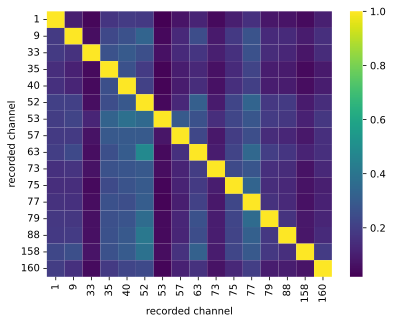

In [5]:
from src.process_ripple import process_neural_data, get_channel_stats

spike_times, _ = process_neural_data(nsfile, monkey=monkey, use_semantic_channel_labels=False)
spike_mat = (
    spike_times
    .pipe(smile_extract.bin_spikes_in_trial, bin_size='1ms')
    .droplevel(level='unit',axis='columns')
    .rename_axis('recorded channel',axis=1)
    .sort_index(axis=1)
    .assign(trial_id=0)
    .set_index('trial_id', append=True)
)
channel_stats = get_channel_stats(spike_mat, max_fano=1e7, max_coincidence=0.5)
spike_mat_select = (
    spike_mat
    .loc[:, channel_stats.index[channel_stats['pass']]]
    .fillna(0) # sometimes there's missing data, maybe from some packet drops in Trellis?
)
select_coincidence = (
    (spike_mat_select.T @ spike_mat_select)
    / spike_mat_select.sum(axis=0)
)
sns.heatmap(select_coincidence, cmap='viridis')
channel_stats['pass'].value_counts()

In [7]:
channel_stats.loc[channel_stats['pass']].index

Index([1, 9, 33, 35, 40, 52, 53, 57, 63, 73, 75, 77, 79, 88, 158, 160], dtype='int64', name='recorded channel')

In [5]:
spike_times

,channel,unit,timestamp
snippet_id,,,
0,1,0,0 days 00:00:00.124966667
1,1,0,0 days 00:00:01.183933333
2,1,0,0 days 00:00:01.476833333
3,1,0,0 days 00:00:02.444266667
4,1,0,0 days 00:00:02.561866667
...,...,...,...
32021,160,0,0 days 00:03:12.025700
32022,160,0,0 days 00:03:12.045800
32023,160,0,0 days 00:03:12.051300


In [6]:
from src.process_ripple import process_waveforms
waveforms = pd.DataFrame(
    process_waveforms(nsfile, monkey=monkey),
)

No stimulation entities found in the provided NSFile.


In [30]:
import altair as alt
base = alt.Chart(
    waveforms
    .xs(level='channel',key='PMd.chan077')
    .xs(level='unit',key=0)
    .stack()
    .reset_index(name='amplitude')
)

alt.data_transformers.enable('json')
(
    base
    .mark_line()
    .encode(
        x='snippet frame',
        y='amplitude',
        # color='snippet_id:N'
        detail='snippet_id:N'
    )
)

alt.Chart(...)